# S6E5 — Download e EDA

## 1. Imports e configuração

In [1]:
# Executar apenas se mltemplate não estiver instalado
# import sys
# !"{{sys.executable}}" -m pip install -e "D:\\data_science\\projects\\mltemplate[kaggle,xgboost,lightgbm]"

In [2]:
from pathlib import Path

from mltemplate.config import ProjectConfig
from mltemplate.storage import StorageManager
from mltemplate.data import KaggleSource, DataManager
from mltemplate import eda

import pandas as pd
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO)

In [3]:
config = ProjectConfig(
    target="PitNextLap",                                                                                                                                                                   # ajuste para o nome real da coluna alvo
    numerical_features=["Year", "LapNumber", "Stint", "TyreLife", "Position", "LapTime (s)", "LapTime_Delta", "Cumulative_Degradation", "RaceProgress", "Position_Change"],                # preencha após ver o dataset
    categorical_features=["Compound", "Race", "PitStop"],                                                                                                                                  # preencha após ver o dataset
    ignore_features=["id"],                                                                                                                                                                # ajuste se necessário
    problem_type="classification",
)

storage = StorageManager(root=Path("."))
dm      = DataManager(storage, config)

## 2. Download dos dados

In [4]:
source = KaggleSource("playground-series-s6e5")
train_df, test_df = dm.load_raw(source)

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")

INFO:mltemplate.data.sources:Dados já existentes em data\raw — download ignorado.
INFO:mltemplate.data.manager:Dados brutos carregados — treino (439140, 16), teste (188165, 15)


Train: (439140, 16)
Test:  (188165, 15)


## 3. Informações gerais

**`dataset_info`**

- **O que faz:** lista, por coluna, o tipo de dado, a contagem e o percentual de valores nulos, o número de valores únicos e o percentual de únicos pelo total de linhas.
- **Base teórica:** verifica qualidade dos dados — tipagem, completude e cardinalidade.
- **O que observar:** colunas com `null_pct` alto (imputar ou descartar); `nunique = 1` (constantes, sem informação); `unique_pct` alto em colunas numéricas pode indicar ID ou chave (sem poder preditivo); `unique_pct` muito alto em categóricas indica alta cardinalidade (cuidado no encoding).

In [ ]:
eda.dataset_info(train_df)

In [ ]:
eda.dataset_info(test_df)

## 4. Estatísticas descritivas

> Preencha `numerical_features` e `categorical_features` no `ProjectConfig` (célula acima) antes de executar.

**`summary_statistics`**

- **O que faz:** estatísticas descritivas separadas por grupo (target, numéricas, categóricas).
- **Base teórica:** momentos (média, desvio) e quantis resumem centralidade, dispersão e assimetria da distribuição.
- **O que observar:** distância entre média e mediana (p50) indica assimetria; desvio alto frente à amplitude sugere outliers; no target, o balanceamento das classes.

In [7]:
stats = eda.summary_statistics(train_df, config)
for key, df in stats.items():
    print(key)
    display(df)

target


,count,nunique,mode,value_counts,frequencies
PitNextLap(float64),439140,2,0.0,"{0.0: 351759, 1.0: 87381}","{0.0: 0.801, 1.0: 0.199}"


numerical


,Year,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542
std,1.024930,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765
min,2022.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000
max,2025.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000
p25,2023.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000
p50,2024.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000
p75,2024.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000


categorical


,Compound,Race,PitStop
count,439140,439140,439140
nunique,5,26,2
mode,MEDIUM,Dutch Grand Prix,0


## 5. Distribuição do target

**`plot_target_distribution`**

- **O que faz:** distribuição da variável-alvo — barras com contagem e % por classe (classificação) ou histograma + KDE (regressão).
- **Base teórica:** o balanceamento/forma do target define a estratégia de modelagem (métrica, reamostragem, pesos, transformação).
- **O que observar:** desbalanceamento severo entre classes; no caso contínuo, assimetria ou multimodalidade que sugiram transformar o target (ex.: log).

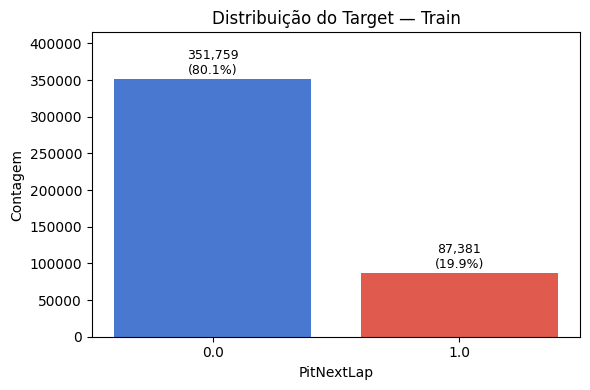

In [8]:
fig = eda.plot_target_distribution(train_df, config, name="Train")
plt.show()

## 6. Features numéricas

**`plot_histogram_by_target`**

- **O que faz:** histograma de cada feature numérica, colorido pela classe (ou quartil) do target. Eixo cortado em [P1, P99].
- **Base teórica:** estima a densidade empírica por contagem em intervalos; a separação entre as cores indica poder discriminativo da feature.
- **O que observar:** features com distribuições por classe bem separadas (boas preditoras); sobreposição total (pouco informativas); forma (assimetria, caudas, multimodalidade).

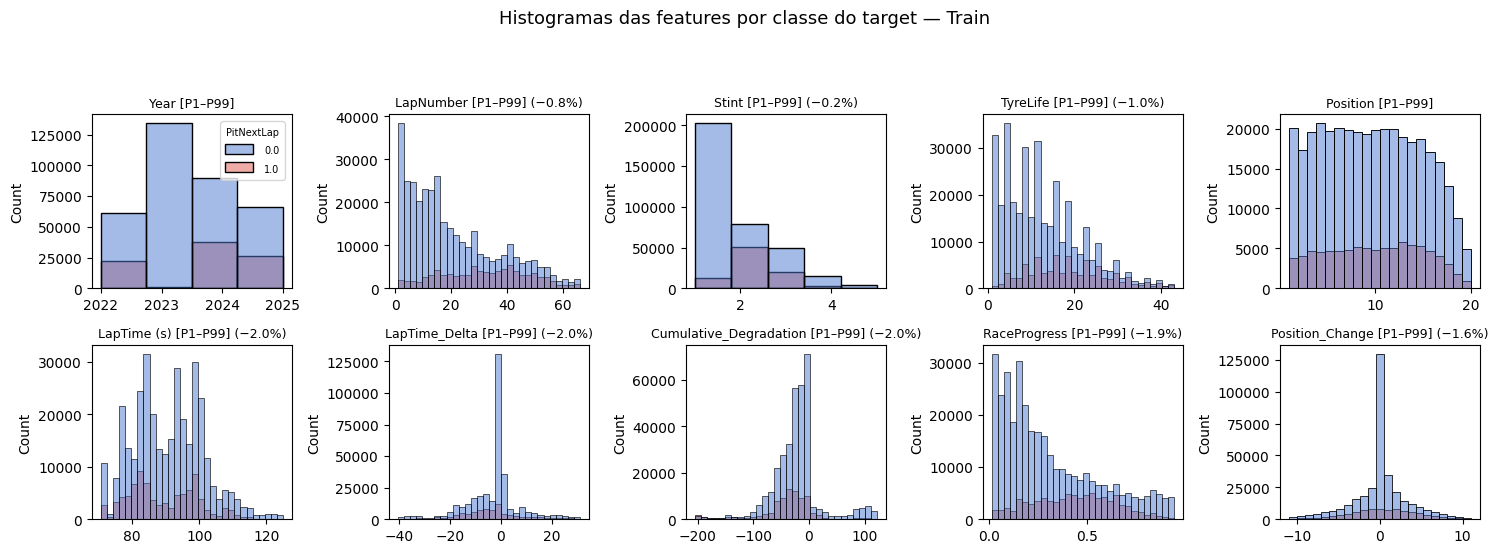

In [9]:
fig = eda.plot_histogram_by_target(train_df, config, name="Train")
plt.show()

**`plot_boxplot_by_target`**

- **O que faz:** boxplot de cada feature por classe/quartil do target.
- **Base teórica:** resume a distribuição em cinco números (mín, Q1, mediana, Q3, máx) e marca outliers além das cercas de Tukey (1.5·IQR).
- **O que observar:** diferença de mediana entre grupos (poder discriminativo); largura da caixa (dispersão); volume de pontos fora das cercas.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

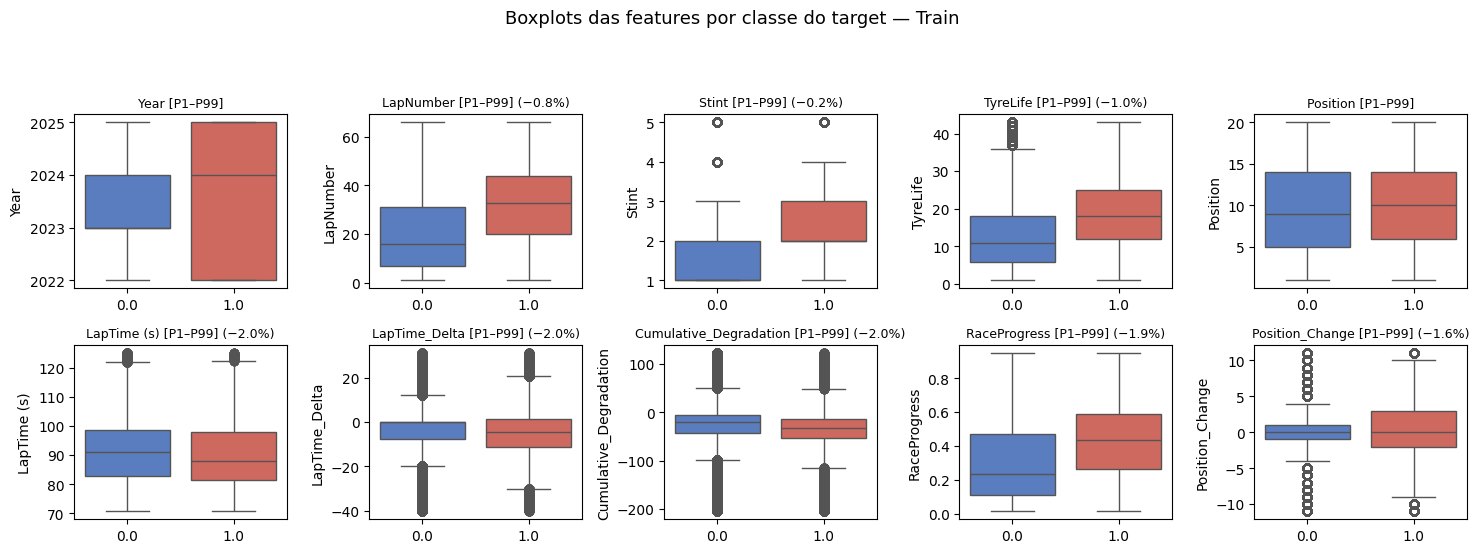

In [10]:
fig = eda.plot_boxplot_by_target(train_df, config, name="Train")
plt.show()

**`plot_violin_by_target`**

- **O que faz:** combina o boxplot com a densidade (KDE) espelhada, por classe/quartil.
- **Base teórica:** mostra a forma completa da distribuição — revela multimodalidade que o boxplot esconde.
- **O que observar:** diferença de formato entre grupos; múltiplos picos; concentração de massa em regiões distintas.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

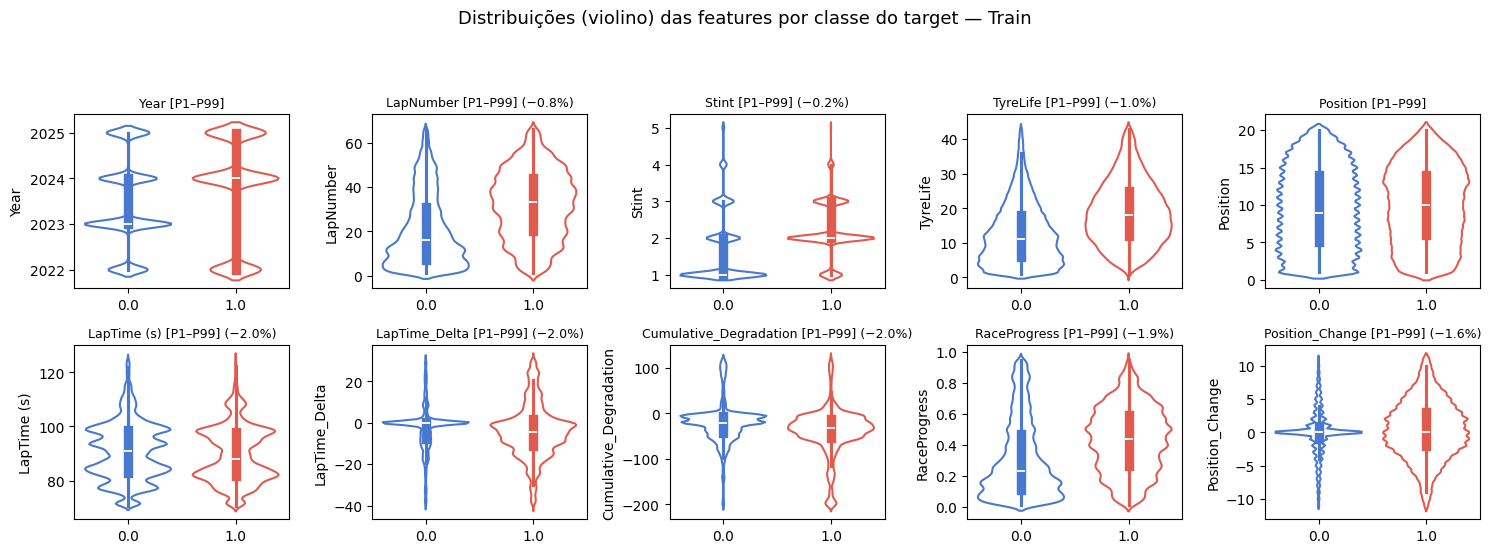

In [11]:
fig = eda.plot_violin_by_target(train_df, config, name="Train")
plt.show()

**`plot_kde_by_target`**

- **O que faz:** curva de densidade suavizada de cada feature por classe/quartil (cada curva normalizada de forma independente).
- **Base teórica:** estimativa por kernel — versão contínua do histograma, sem dependência da escolha de bins.
- **O que observar:** sobreposição entre curvas (menor = mais discriminativa); deslocamento da moda entre classes; caudas pesadas.

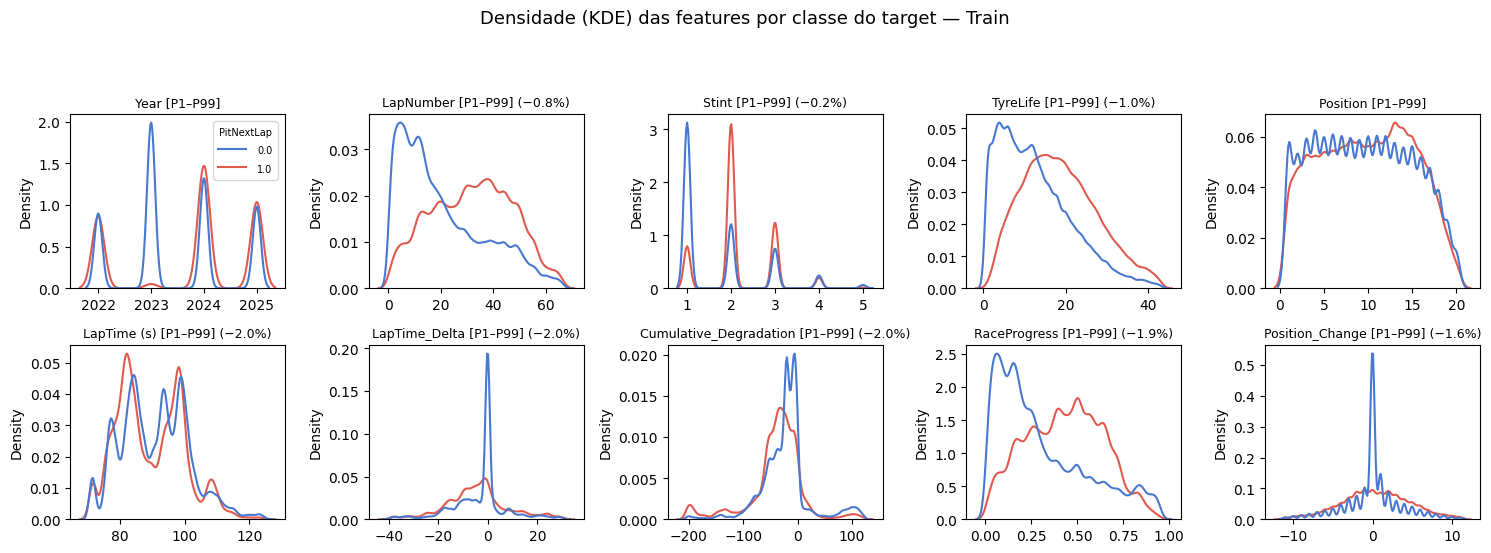

In [12]:
fig = eda.plot_kde_by_target(train_df, config, name="Train")
plt.show()

**`plot_correlation_heatmap`**

- **O que faz:** matriz de correlação (Pearson por padrão) entre as features numéricas.
- **Base teórica:** Pearson mede associação **linear** em [-1, 1]; Spearman captura monotonia. Correlação alta entre features indica multicolinearidade (redundância).
- **O que observar:** pares com |correlação| alta (candidatos a remoção/combinação); blocos de features correlacionadas.

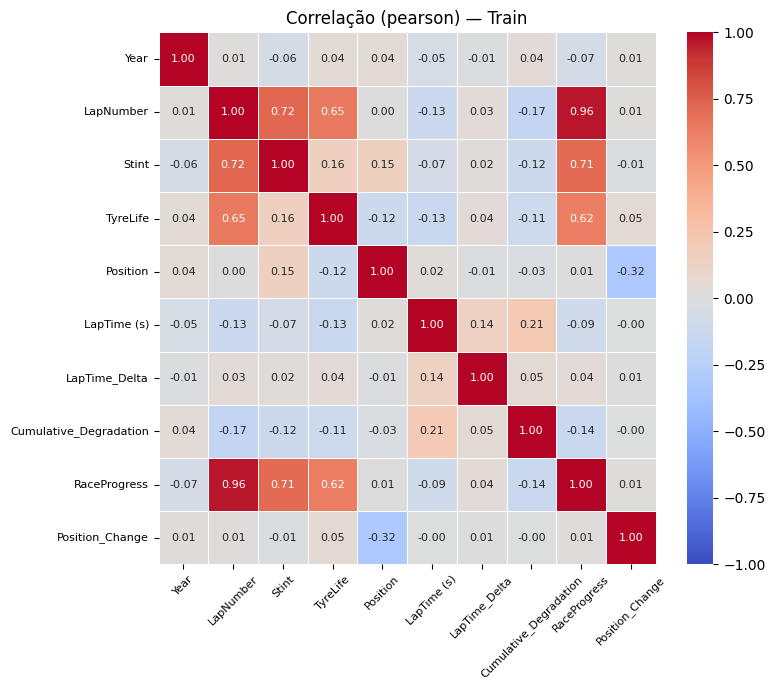

In [13]:
fig = eda.plot_correlation_heatmap(train_df, config, method = "pearson", name = "Train")
plt.show()

### Outliers

**`outlier_summary`**

- **O que faz:** conta outliers por feature numérica pelo critério IQR (fora de [Q1−1.5·IQR, Q3+1.5·IQR]).
- **Base teórica:** a regra de Tukey define outliers de forma robusta, sem assumir normalidade.
- **O que observar:** features com `pct_outliers` alto (avaliar winsorização/transformação); cercas muito distantes do mín/máx real indicam caudas longas.

In [14]:
eda.outlier_summary(train_df, config)

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
Year,2023.0000,2024.0000,1.0000,2021.5000,2025.5000,0,0.00
LapNumber,9.0000,36.0000,27.0000,-31.5000,76.5000,16,0.00
Stint,1.0000,2.0000,1.0000,-0.5000,3.5000,24078,5.48
TyreLife,6.0000,20.0000,14.0000,-15.0000,41.0000,5711,1.30
Position,5.0000,14.0000,9.0000,-8.5000,27.5000,0,0.00
LapTime (s),82.6210,98.4710,15.8500,58.8460,122.2460,5905,1.34
LapTime_Delta,-8.8840,0.1150,8.9990,-22.3825,13.6135,58900,13.41
Cumulative_Degradation,-46.5663,-6.1990,40.3673,-107.1171,54.3519,49869,11.36
RaceProgress,0.1299,0.5132,0.3833,-0.4451,1.0881,0,0.00
Position_Change,-1.0000,2.0000,3.0000,-5.5000,6.5000,61180,13.93


## 7. Features categóricas

**`plot_barplot_by_target`**

- **O que faz:** classificação — contagem de cada categoria colorida pela classe do target; regressão — distribuição do target por categoria.
- **Base teórica:** visualização da tabela de contingência (ou da E[target|categoria]); revela associação entre a categórica e o target.
- **O que observar:** categorias com proporção de classe distante da média global (preditoras); níveis raros (risco de overfitting no encoding).

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


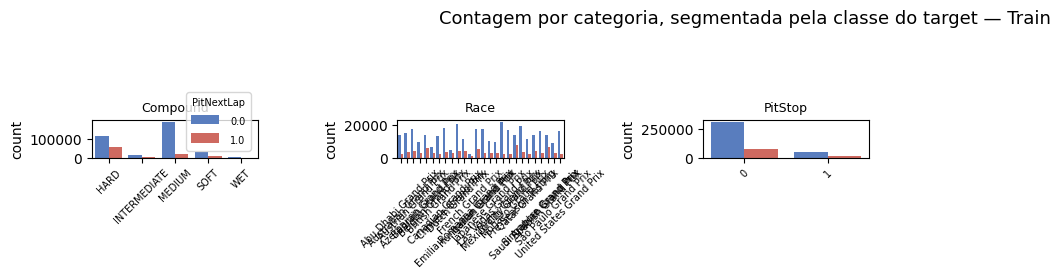

In [15]:
fig = eda.plot_barplot_by_target(train_df, config, name="Train")
plt.show()

### Taxa do Target por Categoria

**`category_target_rate`**

- **O que faz:** taxa média do target por nível de cada categórica (proporção positiva em classificação; média ± desvio em regressão).
- **Base teórica:** estima E[target | categoria] — fundamento do target/mean encoding.
- **O que observar:** níveis com taxa muito acima/abaixo da média global (sinal forte); confiar mais em níveis com `count` alto.

In [16]:
rates = eda.category_target_rate(train_df, config)
for col, df_rate in rates.items():
    display(df_rate)

,count,rate
Compound,,
HARD,170518,0.3275
SOFT,38744,0.1935
INTERMEDIATE,17382,0.1523
MEDIUM,211141,0.1011
WET,1355,0.0251


,count,rate
Race,,
Chinese Grand Prix,7311,0.3886
Monaco Grand Prix,21539,0.3574
Spanish Grand Prix,20483,0.3200
Bahrain Grand Prix,19535,0.2875
Belgian Grand Prix,9002,0.2804
Emilia Romagna Grand Prix,15483,0.2726
French Grand Prix,3185,0.2575
São Paulo Grand Prix,11497,0.2537
Hungarian Grand Prix,22481,0.2393


,count,rate
PitStop,,
1,59775,0.2478
0,379365,0.1913


## 8. Informação Mútua

**`mutual_information_scores`**

- **O que faz:** informação mútua entre cada feature e o target, ordenada (decrescente).
- **Base teórica:** MI mede a redução de entropia sobre o target ao conhecer a feature; captura relações **não-lineares** que a correlação ignora. MI = 0 ⇔ independência.
- **O que observar:** ranking de importância univariada; MI alto (priorizar); MI ≈ 0 (candidatas a descarte). Atenção: é univariada, não captura interações entre features.

In [17]:
eda.mutual_information_scores(train_df, config)

,mi_score
feature,
RaceProgress,0.0971
Stint,0.0750
Year,0.0711
LapTime_Delta,0.0602
Cumulative_Degradation,0.0531
LapNumber,0.0467
TyreLife,0.0402
Position_Change,0.0359
Compound,0.0356


## 9. Evolução por Volta

**`plot_feature_over_sequence`**

- **O que faz:** evolução da média de cada feature ao longo de uma coluna sequencial, segmentada por classe/quartil do target.
- **Base teórica:** em dados sequenciais/temporais, revela tendência, sazonalidade e o ponto onde os grupos divergem.
- **O que observar:** tendências (crescente/decrescente); ponto em que as curvas das classes se separam (janelas informativas); rupturas abruptas.

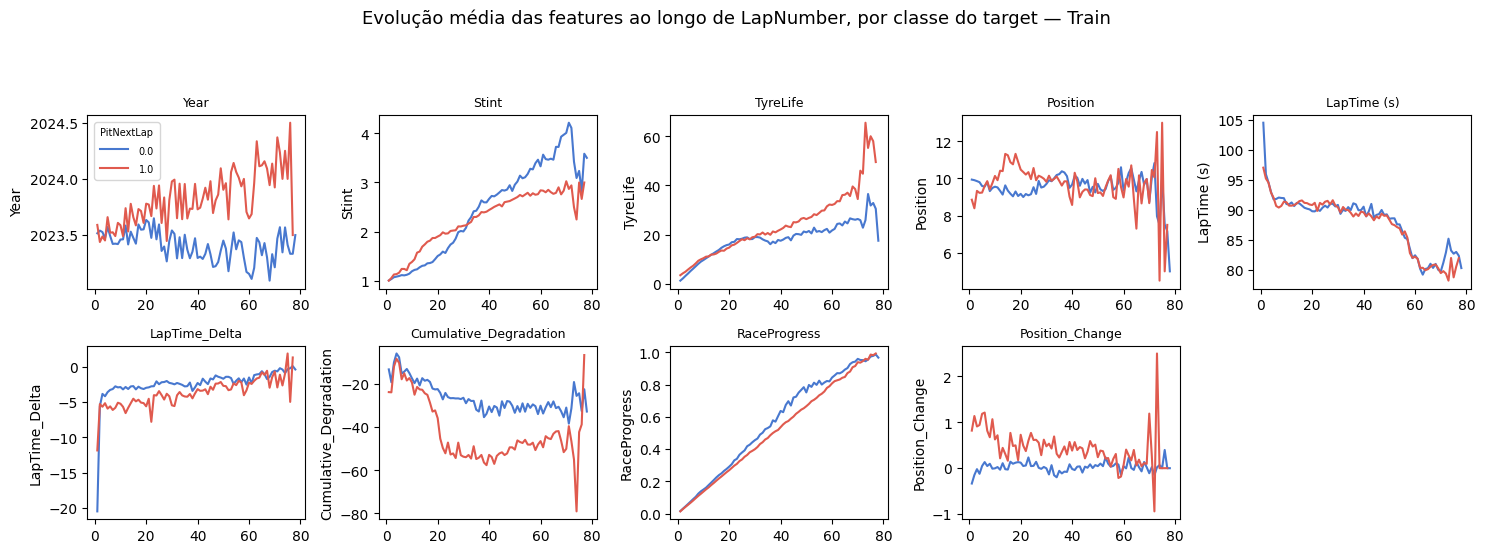

In [25]:
fig = eda.plot_feature_over_sequence(train_df, config, sequence_col="LapNumber", name="Train")
plt.show()

## 10. Train vs Test (distribuição das features numéricas)

**`plot_boxplot_comparative`**

- **O que faz:** boxplot de cada feature numérica comparando dois conjuntos (treino vs teste).
- **Base teórica:** detecta *covariate shift* — diferença de distribuição entre treino e teste que prejudica a generalização.
- **O que observar:** features com mediana/dispersão distintas entre conjuntos (drift); faixa de valores no teste não vista no treino (extrapolação).

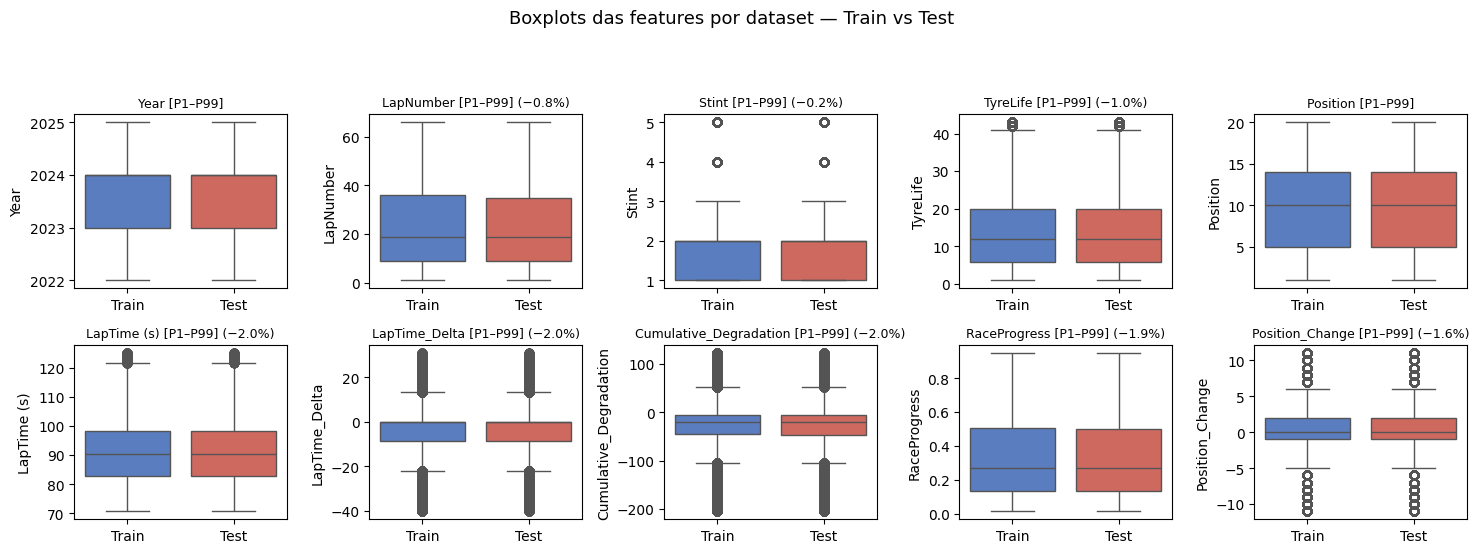

In [19]:
fig = eda.plot_boxplot_comparative(train_df, test_df, config, name1="Train", name2="Test")
plt.show()

**`plot_kde_comparative`**

- **O que faz:** densidade KDE de cada feature comparando treino vs teste (cada curva normalizada por grupo).
- **Base teórica:** versão contínua do comparativo; a sobreposição das curvas indica estabilidade da distribuição.
- **O que observar:** descolamento entre as curvas (shift na forma, não só na mediana); modas em posições diferentes; caudas presentes só em um conjunto.

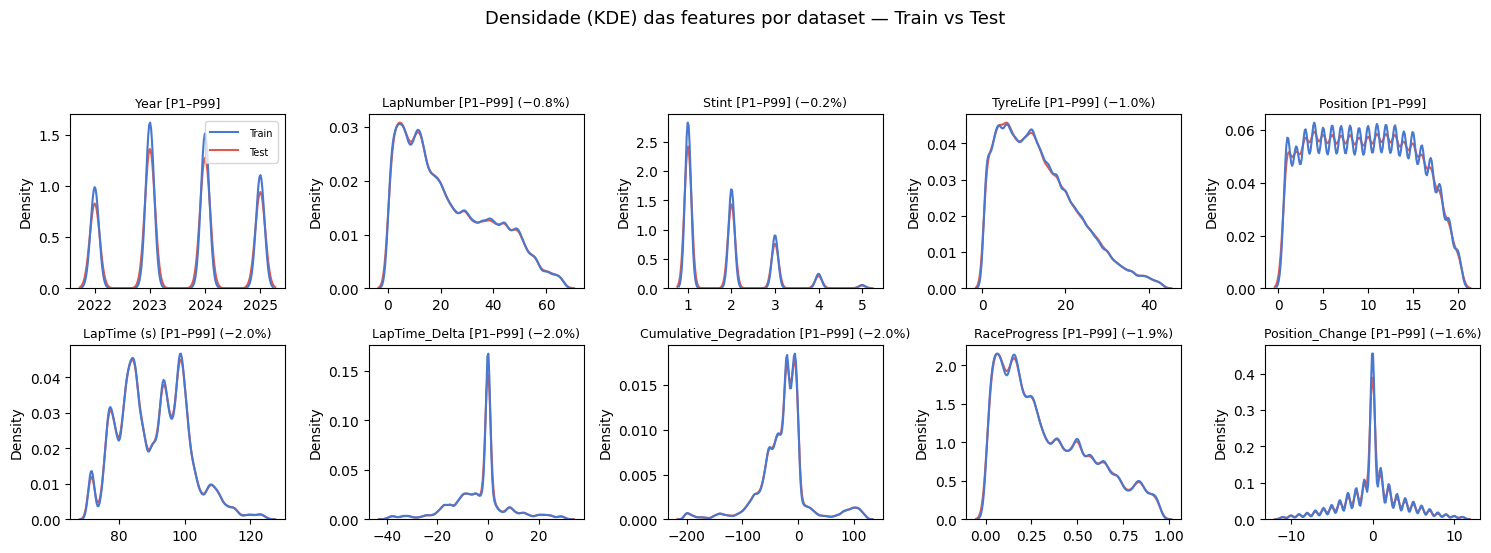

In [20]:
fig = eda.plot_kde_comparative(train_df, test_df, config, name1="Train", name2="Test")
plt.show()

## 11. Observações

> **Próximos passos:** passar para `02_features.ipynb`.

## 12. Regressão — funções específicas

> As células abaixo são exclusivas de **problemas de regressão**. Descomente e execute ao trabalhar com um target contínuo.

**`plot_scatter_feature_vs_target`** *(regressão)*

- **O que faz:** dispersão de cada feature vs o target contínuo, com linha de tendência LOWESS.
- **Base teórica:** o scatter revela a forma da relação; o LOWESS é uma regressão local não-paramétrica que estima E[target|feature] sem assumir forma funcional.
- **O que observar:** linearidade vs. curvatura (necessidade de transformação/termos polinomiais); heterocedasticidade (variância do target cresce com a feature); platôs e pontos de inflexão.

In [21]:
# fig = eda.plot_scatter_feature_vs_target(train_df, config, name="Train")
# plt.show()

**`plot_feature_target_correlation`** *(regressão)*

- **O que faz:** barras horizontais da correlação de cada feature com o target, ordenadas por magnitude.
- **Base teórica:** Pearson quantifica a associação linear feature-target; o sinal indica a direção.
- **O que observar:** features no topo (preditoras lineares fortes); sinal (relação direta/inversa); valores perto de zero ainda podem ter relação não-linear — cruzar com a informação mútua.

In [22]:
# fig = eda.plot_feature_target_correlation(train_df, config, name="Train")
# plt.show()

**`plot_target_by_categorical`** *(regressão)*

- **O que faz:** boxplot da distribuição do target por nível de cada feature categórica.
- **Base teórica:** compara E[target|categoria] e a dispersão entre grupos — equivalente visual de uma ANOVA.
- **O que observar:** categorias com mediana do target distinta (preditoras); variância heterogênea entre níveis; níveis com poucos pontos (caixas instáveis).

In [23]:
# fig = eda.plot_target_by_categorical(train_df, config, name="Train")
# plt.show()